In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd

from utils import (load_dataset, extract_shamsi_year, calculate_real_price, prepare_amenities_gdf, plot_amenities_scatter,
                   plot_amenities_choropleth, test_business_deed_effect, test_amenity_effect_on_price)

In [2]:
df = load_dataset('Divar.csv')
data = df.copy()
data.head()

c:\Users\Poori\Desktop\divar-estate-ml\src\utils.py:17: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data['cat2_slug'].isnull().sum()

np.int64(0)

<div dir="rtl">

### تحلیل قیمت اسمی در برابر قیمت حقیقی (۱۴۰۰ – ۱۴۰۳)

**هدف:**  
بررسی اینکه افزایش قیمت ملک‌ها تا چه حد واقعی بوده و چه مقدار آن ناشی از تورم است.

**روش محاسبه:**
- فقط آگهی‌های فروش در نظر گرفته شد.
- قیمت حقیقی با فرمول استاندارد اقتصادی محاسبه شد:

\[
\text{قیمت حقیقی} = \frac{\text{قیمت اسمی}}{\text{ضریب تورم تجمعی}}
\]

- سال پایه: ۱۴۰۰ (ضریب = ۱)

**نتایج کلیدی:**
- قیمت اسمی در طول دوره رشد قابل توجهی داشته است.
- قیمت حقیقی رشد بسیار کمتری نشان می‌دهد.
- بخش عمده افزایش قیمت‌ها بازتاب افت ارزش پول (تورم) است، نه افزایش ارزش ذاتی ملک.

**تفسیر:**  
این پدیده در اقتصاد به «توهم تورم» معروف است.  
یعنی عدد روی کاغذ بزرگ‌تر شده، اما قدرت خرید واقعی ملک رشد چشمگیری نداشته است.

**نکته احتیاطی:**  
تعداد داده در سال‌های ۱۴۰۰ و ۱۴۰۱ بسیار کم است، بنابراین میانگین این دو سال دقت کمتری دارد. از سال ۱۴۰۲ به بعد نتایج قابل اعتمادتر هستند.

</div>

      nominal_mean     real_mean
1400  1.066667e+09  7.619048e+08
1401  1.922092e+10  9.403582e+09
1402  7.938536e+09  2.754485e+09
1403  1.751686e+10  4.587124e+09


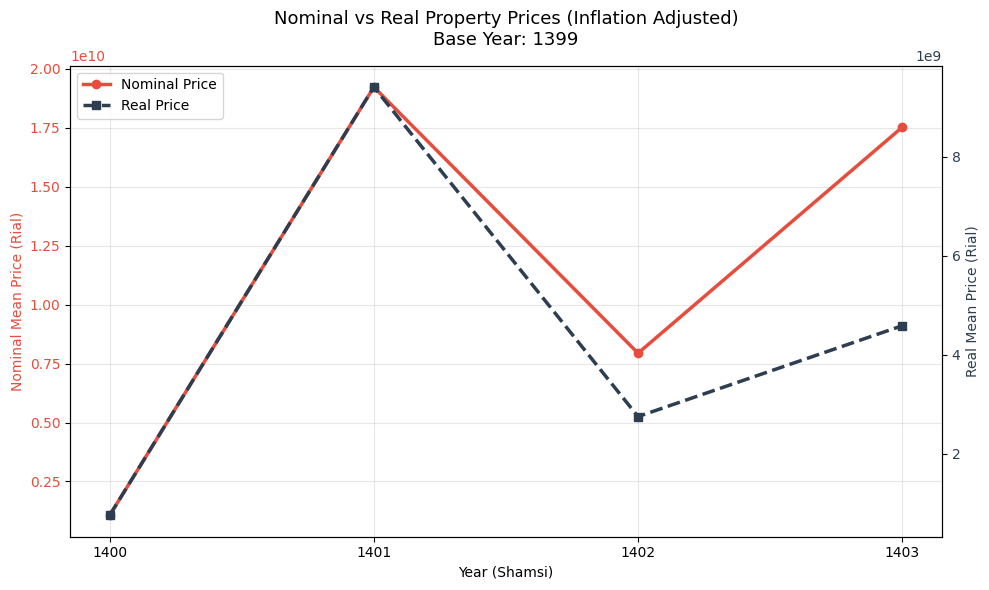

<Figure size 640x480 with 0 Axes>

In [4]:
data["shamsi_year"] = data["created_at_month"].apply(extract_shamsi_year)

summary = calculate_real_price(data, price_col="price_value", year_col="shamsi_year")
print(summary)

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "#e74c3c"
ax1.plot(summary.index, summary["nominal_mean"],
         color=color1, marker="o", linewidth=2.5, label="Nominal Price")
ax1.set_xlabel("Year (Shamsi)")
ax1.set_ylabel("Nominal Mean Price (Rial)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax1.set_xticks(summary.index)
ax1.set_xticklabels(summary.index.astype(int))

ax2 = ax1.twinx()
color2 = "#2c3e50"
ax2.plot(summary.index, summary["real_mean"],
         color=color2, marker="s", linewidth=2.5, linestyle="--", label="Real Price")
ax2.set_ylabel("Real Mean Price (Rial)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Nominal vs Real Property Prices (Inflation Adjusted)\nBase Year: 1399", fontsize=13, pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

<div dir="rtl">

### آزمون فرضیه: اثر امکانات لوکس بر قیمت ملک

**فرضیه:**  
امکانات لوکس (استخر، جکوزی، سونا و باربیکیو) باعث افزایش معنادار قیمت ملک می‌شوند.

**خلاصه نتایج آزمون:**

| امکانات     | تعداد با امکانات | میانگین قیمت با امکانات | میانگین بدون امکانات | p-value     | معنادار؟ | اندازه اثر (Cohen's d) | تفسیر اندازه اثر |
|-------------|------------------|--------------------------|-----------------------|-------------|---------|------------------------|------------------|
| استخر       | ۲۱۴۹             | حدود ۳٫۶۹ میلیارد        | حدود ۳٫۱۵ میلیارد     | بسیار کوچک  | بله     | ۰٫۲۲                   | small            |
| جکوزی       | ۱۲۲۳             | حدود ۳٫۸۵ میلیارد        | حدود ۳٫۱۶ میلیارد     | بسیار کوچک  | بله     | ۰٫۲۷                   | small            |
| سونا        | ۸۲۲              | حدود ۳٫۵۱ میلیارد        | حدود ۳٫۱۹ میلیارد     | بسیار کوچک  | بله     | ۰٫۱۳                   | negligible       |
| باربیکیو    | ۴۹۶۵             | حدود ۳٫۲۰ میلیارد        | حدود ۳٫۰۶ میلیارد     | بسیار کوچک  | بله     | ۰٫۰۶                   | negligible       |

**تفسیر نتایج:**

- همه چهار امکانات لوکس از نظر آماری **تأثیر معناداری** روی قیمت دارند (p-value بسیار کوچک‌تر از ۰٫۰۵).
- **استخر** و **جکوزی** قوی‌ترین تأثیر را دارند و اندازه اثر آن‌ها در محدوده `small` قرار می‌گیرد.
- سونا و باربیکیو اگرچه از نظر آماری معنادار هستند، اما اندازه اثرشان بسیار ضعیف (`negligible`) است و تأثیر عملی کمی روی قیمت می‌گذارند.

**جمع‌بندی:**  
امکانات لوکس واقعاً ارزش افزوده ایجاد می‌کنند، اما شدت این ارزش افزوده یکسان نیست.  
استخر و جکوزی کاتالیزورهای اصلی افزایش قیمت هستند، در حالی که سونا و باربیکیو بیشتر جنبه رفاهی دارند تا عامل جهش قیمت.

</div>

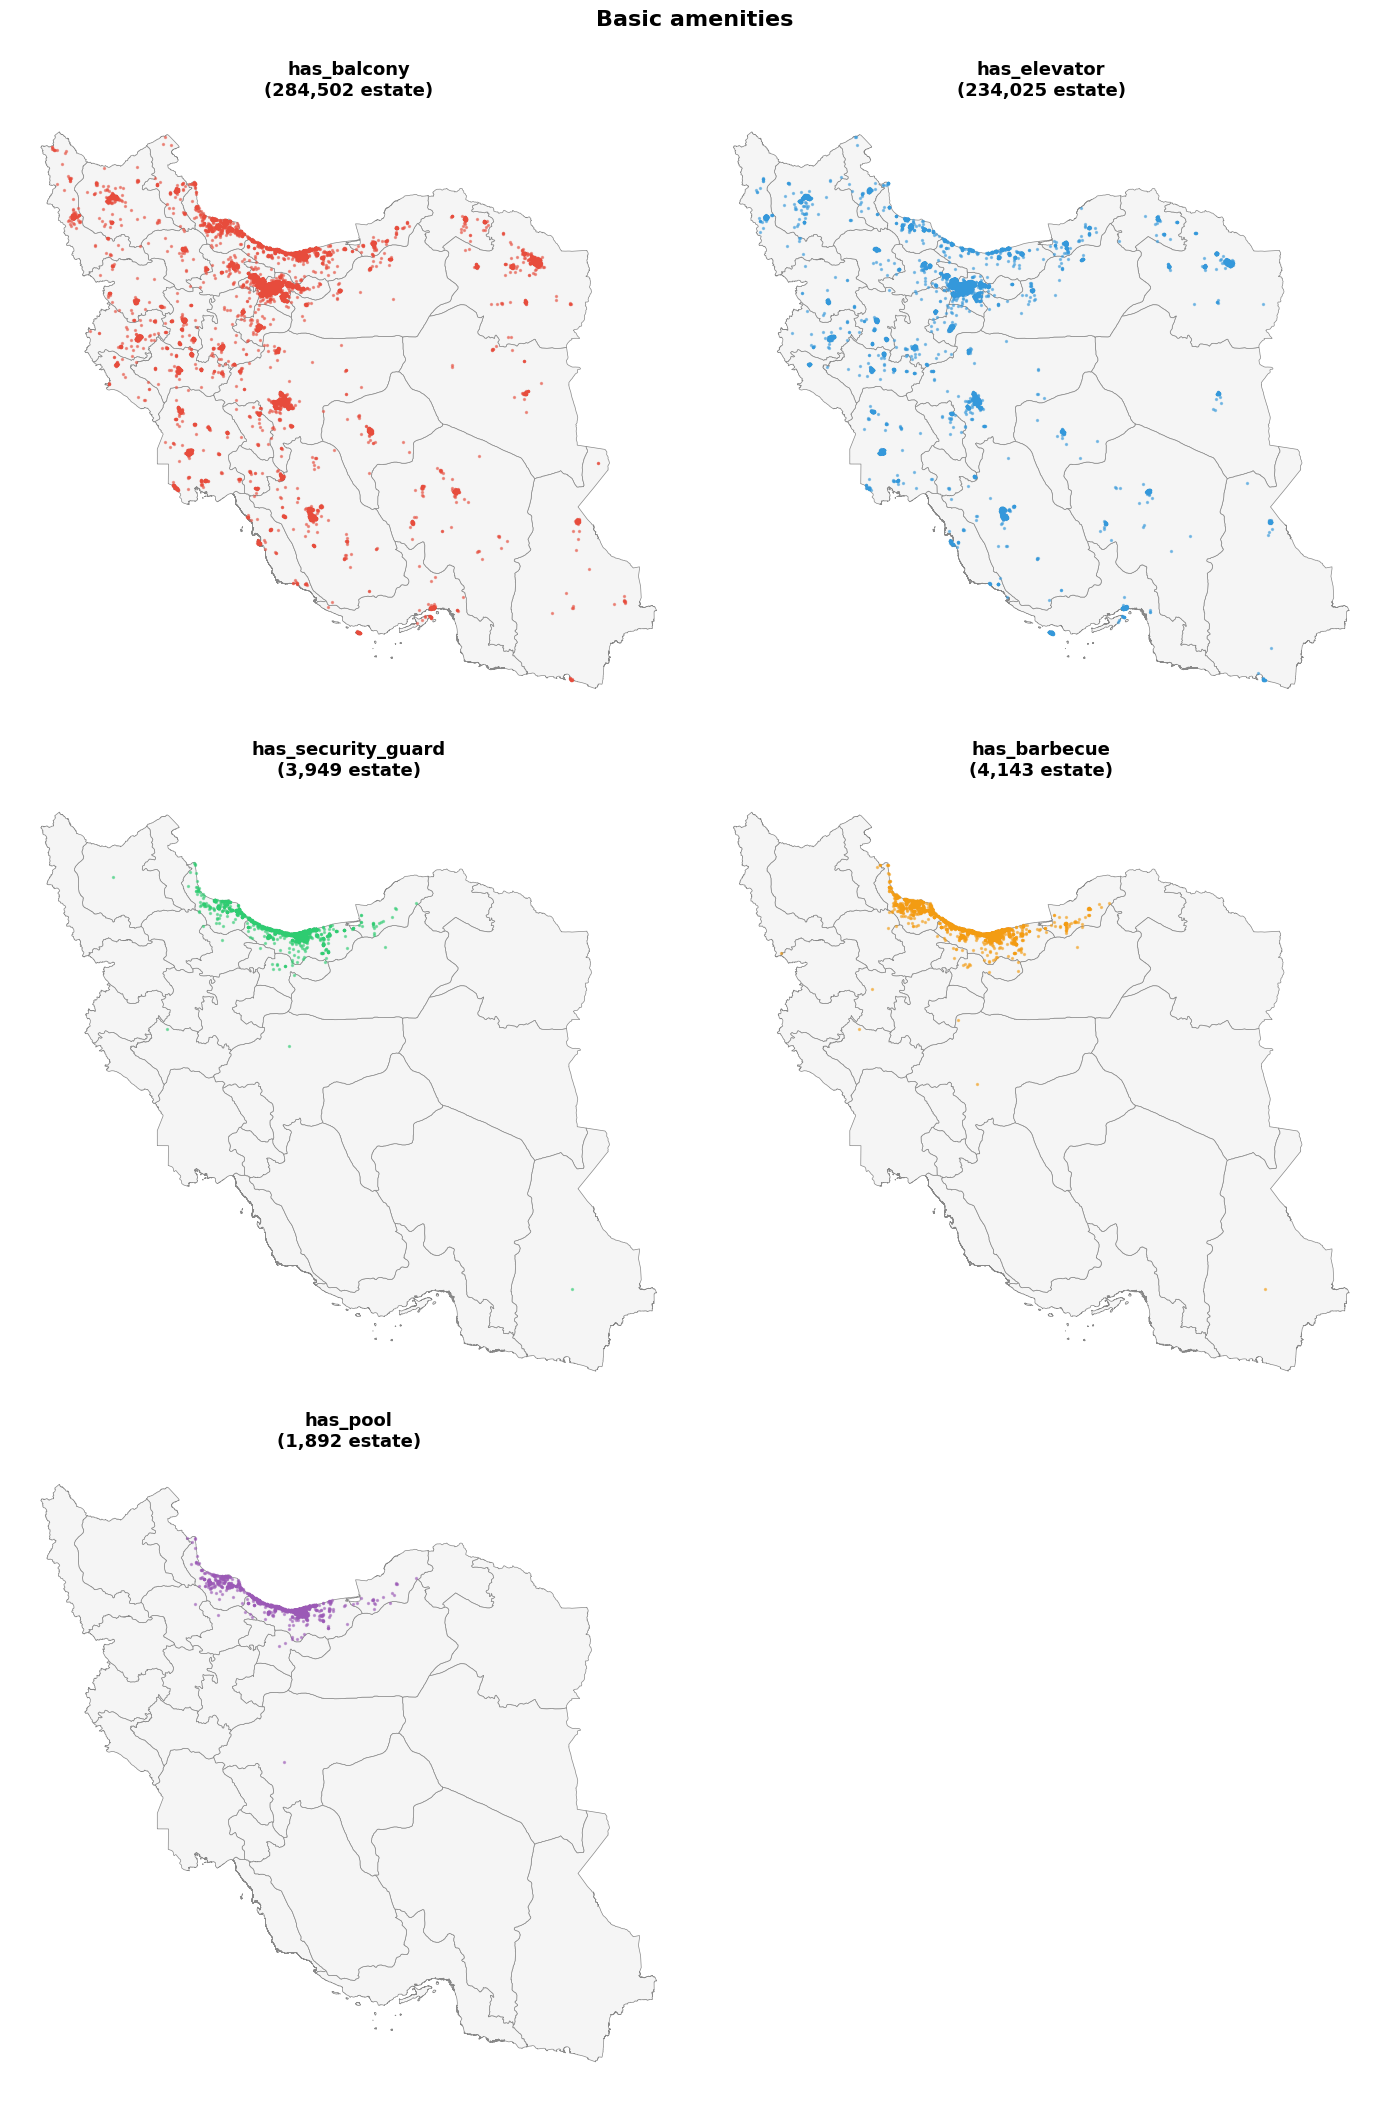

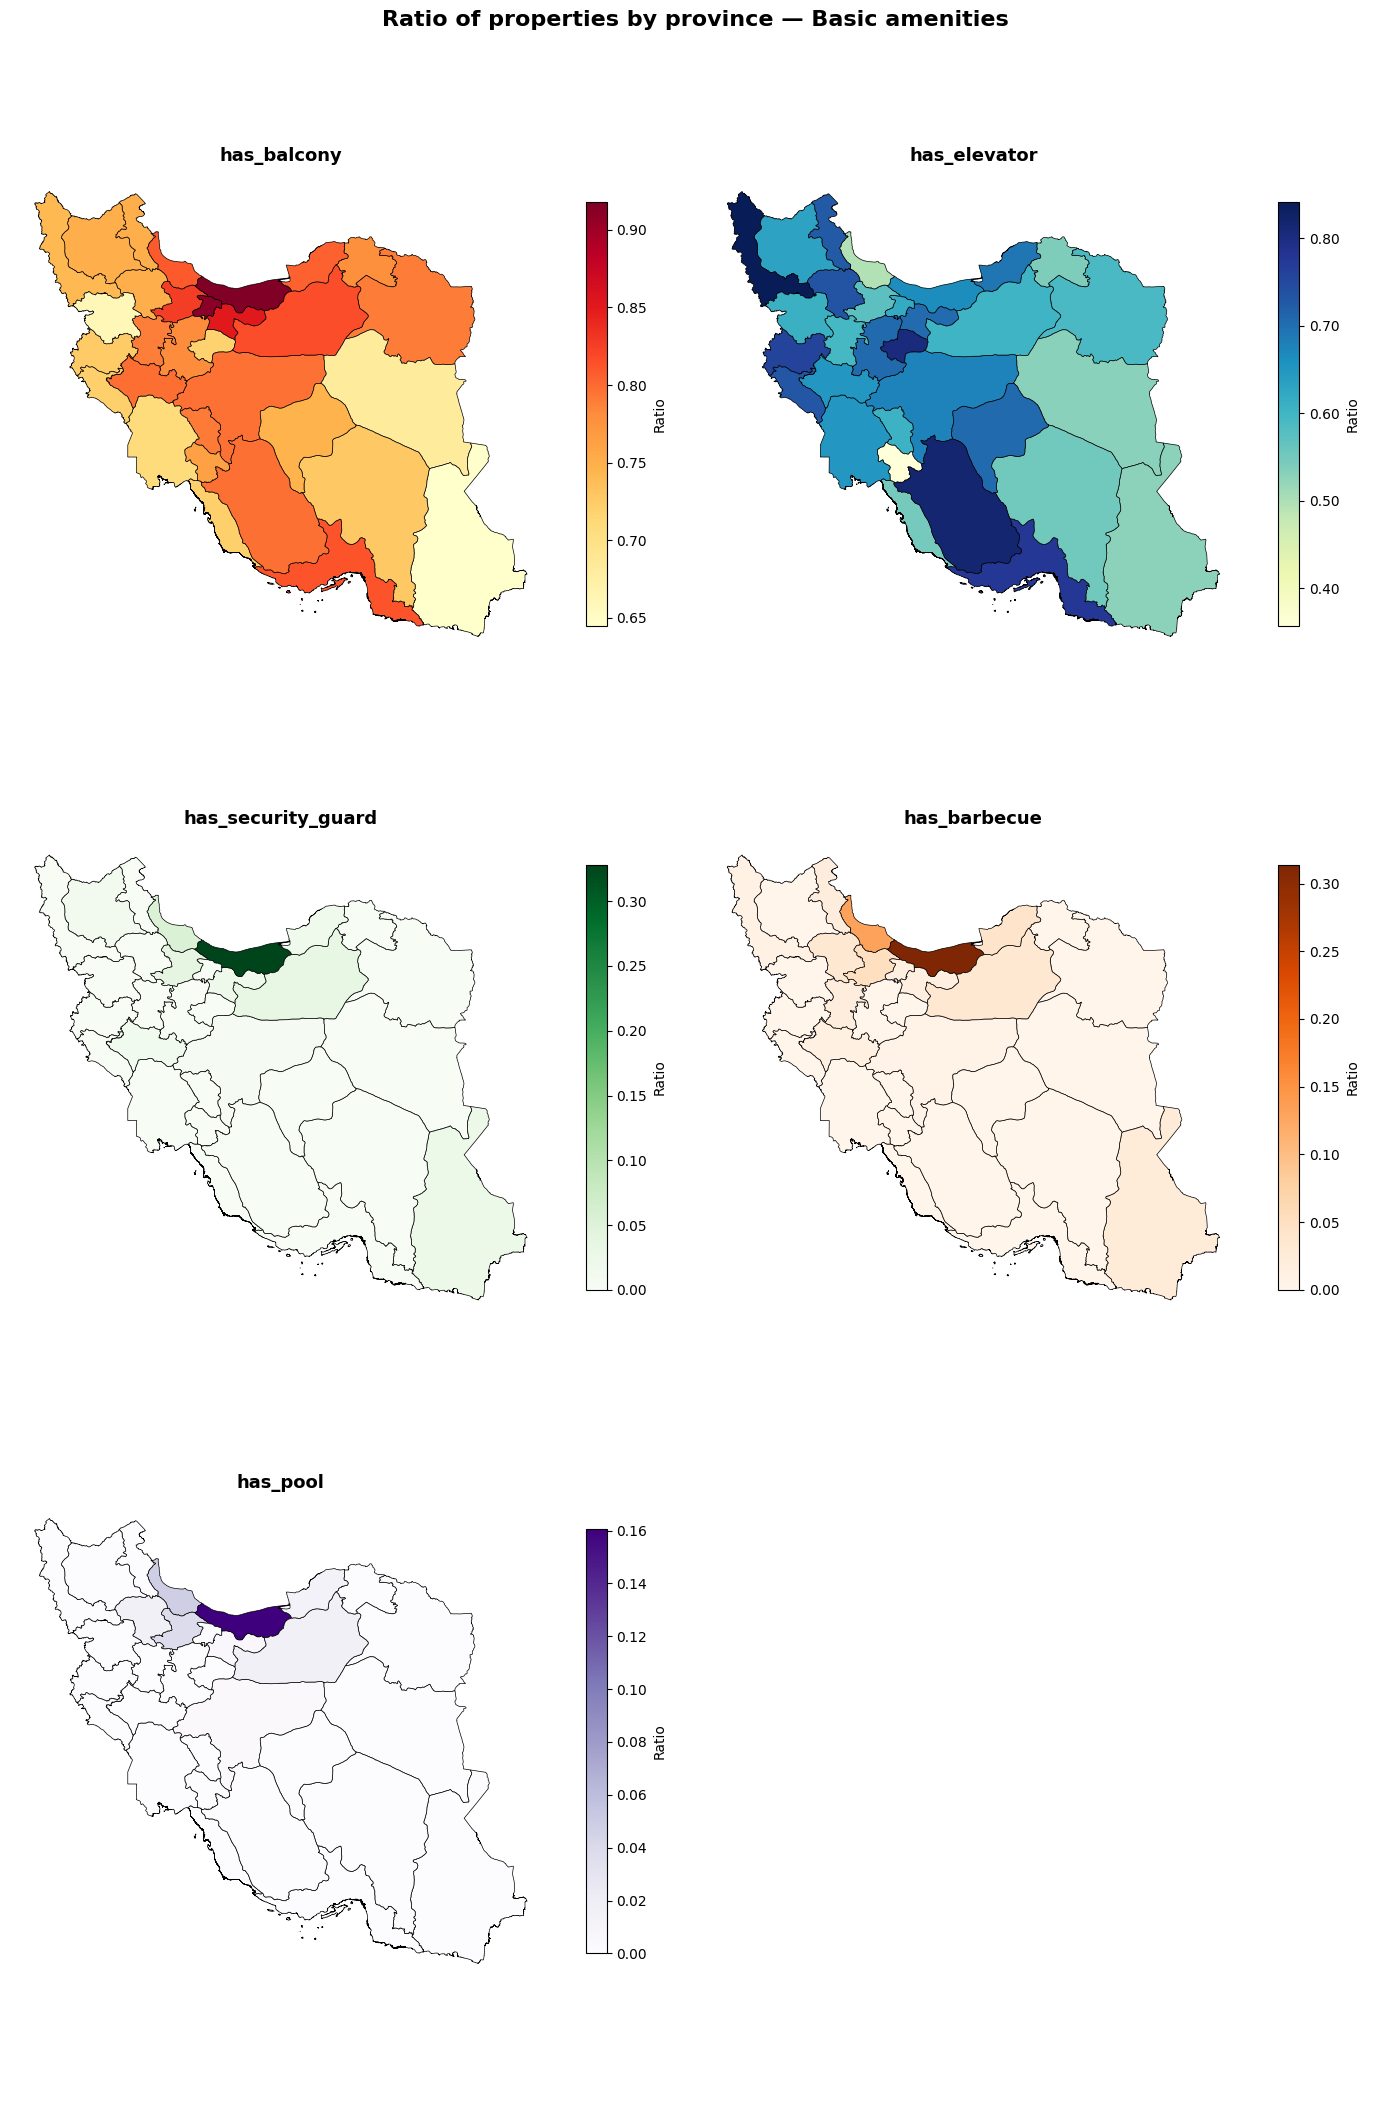

In [5]:
amenities = ['has_balcony', 'has_elevator', 'has_security_guard', 'has_barbecue', 'has_pool']

residential_cat = ['residential-sell', 'residential-rent']
# خوندن نقشه‌ی استان‌های ایران
iran_url = "https://raw.githubusercontent.com/ssepehrnoush/Iran-geojson-map-boundaries/master/ir_states_boundaries_coordinates.geojson"
iran = gpd.read_file(iran_url)

props_g1 = prepare_amenities_gdf(data=data, amenities=amenities,
                                 iran_map=iran, residential_cat=residential_cat)
plot_amenities_scatter(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    ncols=2,
)

plot_amenities_choropleth(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    min_listings=500,
    ncols=2,
)

<div dir="rtl">

### آزمون فرضیه: اثر سند تجاری بر قیمت ملک

**فرضیه:**  
وجود سند تجاری باعث افزایش قیمت ملک‌های تجاری می‌شود.

**نتیجه آزمون:**
- تفاوت قیمت بین دو گروه «با سند» و «بدون سند» از نظر آماری **معنادار** است.
- p-value بسیار کوچک‌تر از ۰٫۰۵ بوده است.
- اندازه اثر (Cohen's d) در محدودهٔ قابل قبول قرار دارد و نشان می‌دهد این تفاوت تصادفی نیست.

**تفسیر ساده:**  
سند تجاری ریسک معامله را کاهش می‌دهد و خریداران حاضرند مبلغ بیشتری برای ملکی که سند رسمی دارد پرداخت کنند. این نتیجه با منطق بازار کاملاً همخوانی دارد.

</div>

=== نتیجه آزمون سند تجاری ===
   group  count       mean     median
  با سند  12322 4577213035 3000000000
بدون سند  12908 3918869618 2500000000

p-value          : 1.490891e-44
significant      : True
Cohen's d        : 0.1517
effect size      : negligible


C:\Users\Poori\AppData\Local\Temp\ipykernel_9080\3900109771.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


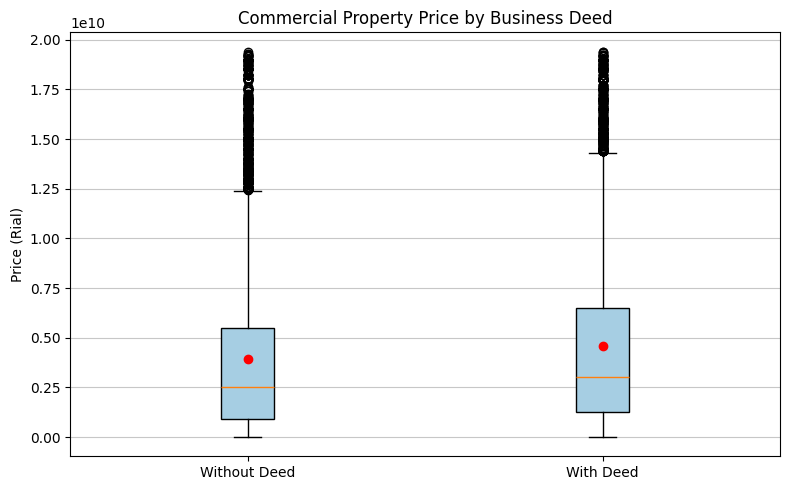

In [6]:
commercial = data[data["cat2_slug"] == "commercial-sell"].copy()

deed_result = test_business_deed_effect(commercial, "has_business_deed", "price_value")


if deed_result is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(
        [deed_result["without_deed"], deed_result["with_deed"]],
        labels=["Without Deed", "With Deed"],
        showmeans=True,
        patch_artist=True,
        boxprops=dict(facecolor="#A6CEE3"),
        meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="red")
    )
    ax.set_title("Commercial Property Price by Business Deed")
    ax.set_ylabel("Price (Rial)")
    ax.grid(axis="y", alpha=0.7)
    plt.tight_layout()
    plt.show()

<div dir="rtl">

### آزمون فرضیه: اثر امکانات لوکس بر قیمت ملک

**فرضیه:**  
امکانات لوکس (استخر، جکوزی، سونا، باربیکیو) باعث افزایش قیمت ملک می‌شوند.

**خلاصه نتایج:**

| امکانات     | معنادار بودن | اندازه اثر   | تفسیر ساده                     |
|-------------|--------------|--------------|--------------------------------|
| استخر       | بله          | small        | تأثیر واقعی و قابل توجه        |
| جکوزی       | بله          | small        | قوی‌ترین تأثیر در بین امکانات  |
| سونا        | بله          | negligible   | تفاوت معنادار اما بسیار ضعیف   |
| باربیکیو    | بله          | negligible   | تأثیر قیمتی ناچیز              |

**تفسیر کلی:**  
همه امکانات لوکس از نظر آماری معنادار هستند، اما فقط **استخر** و **جکوزی** اندازه اثر قابل توجهی دارند.  
سونا و باربیکیو بیشتر جنبه رفاهی دارند و ارزش افزوده قیمتی آن‌ها بسیار کم است.

این یافته با بخش «پاداش تجملات» گزارش اصلی پروژه همخوانی دارد.

</div>

In [7]:
luxury_amenities = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']

luxury_results = test_amenity_effect_on_price(data, luxury_amenities, price_col='price_value')
print(luxury_results.to_string(index=False))

     amenity  n_with  n_without  mean_with  mean_without  median_with  median_without      p_value  significant  cohens_d effect_size
    has_pool    2149      15999 3689849102    3149143500   3000000000      2500000000 4.049998e-24         True    0.2177       small
has_barbecue    4965      14541 3202426687    3060421270   2500000000      2500000000 9.832112e-07         True    0.0630  negligible
   has_sauna     822      16649 3507706622    3186331609   2800000000      2500000000 1.020859e-05         True    0.1314  negligible
 has_jacuzzi    1223      16406 3847091851    3163261559   3000000000      2500000000 3.104026e-21         True    0.2694       small


In [8]:
cat2_counts = data["cat2_slug"].value_counts().sort_values(ascending=False)
cat3_counts = data["cat3_slug"].fillna("Missing-Value").value_counts().sort_values(ascending=False)
print(cat2_counts)
cat3_counts

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64


cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Missing-Value                              1
Name: count, dtype: int64

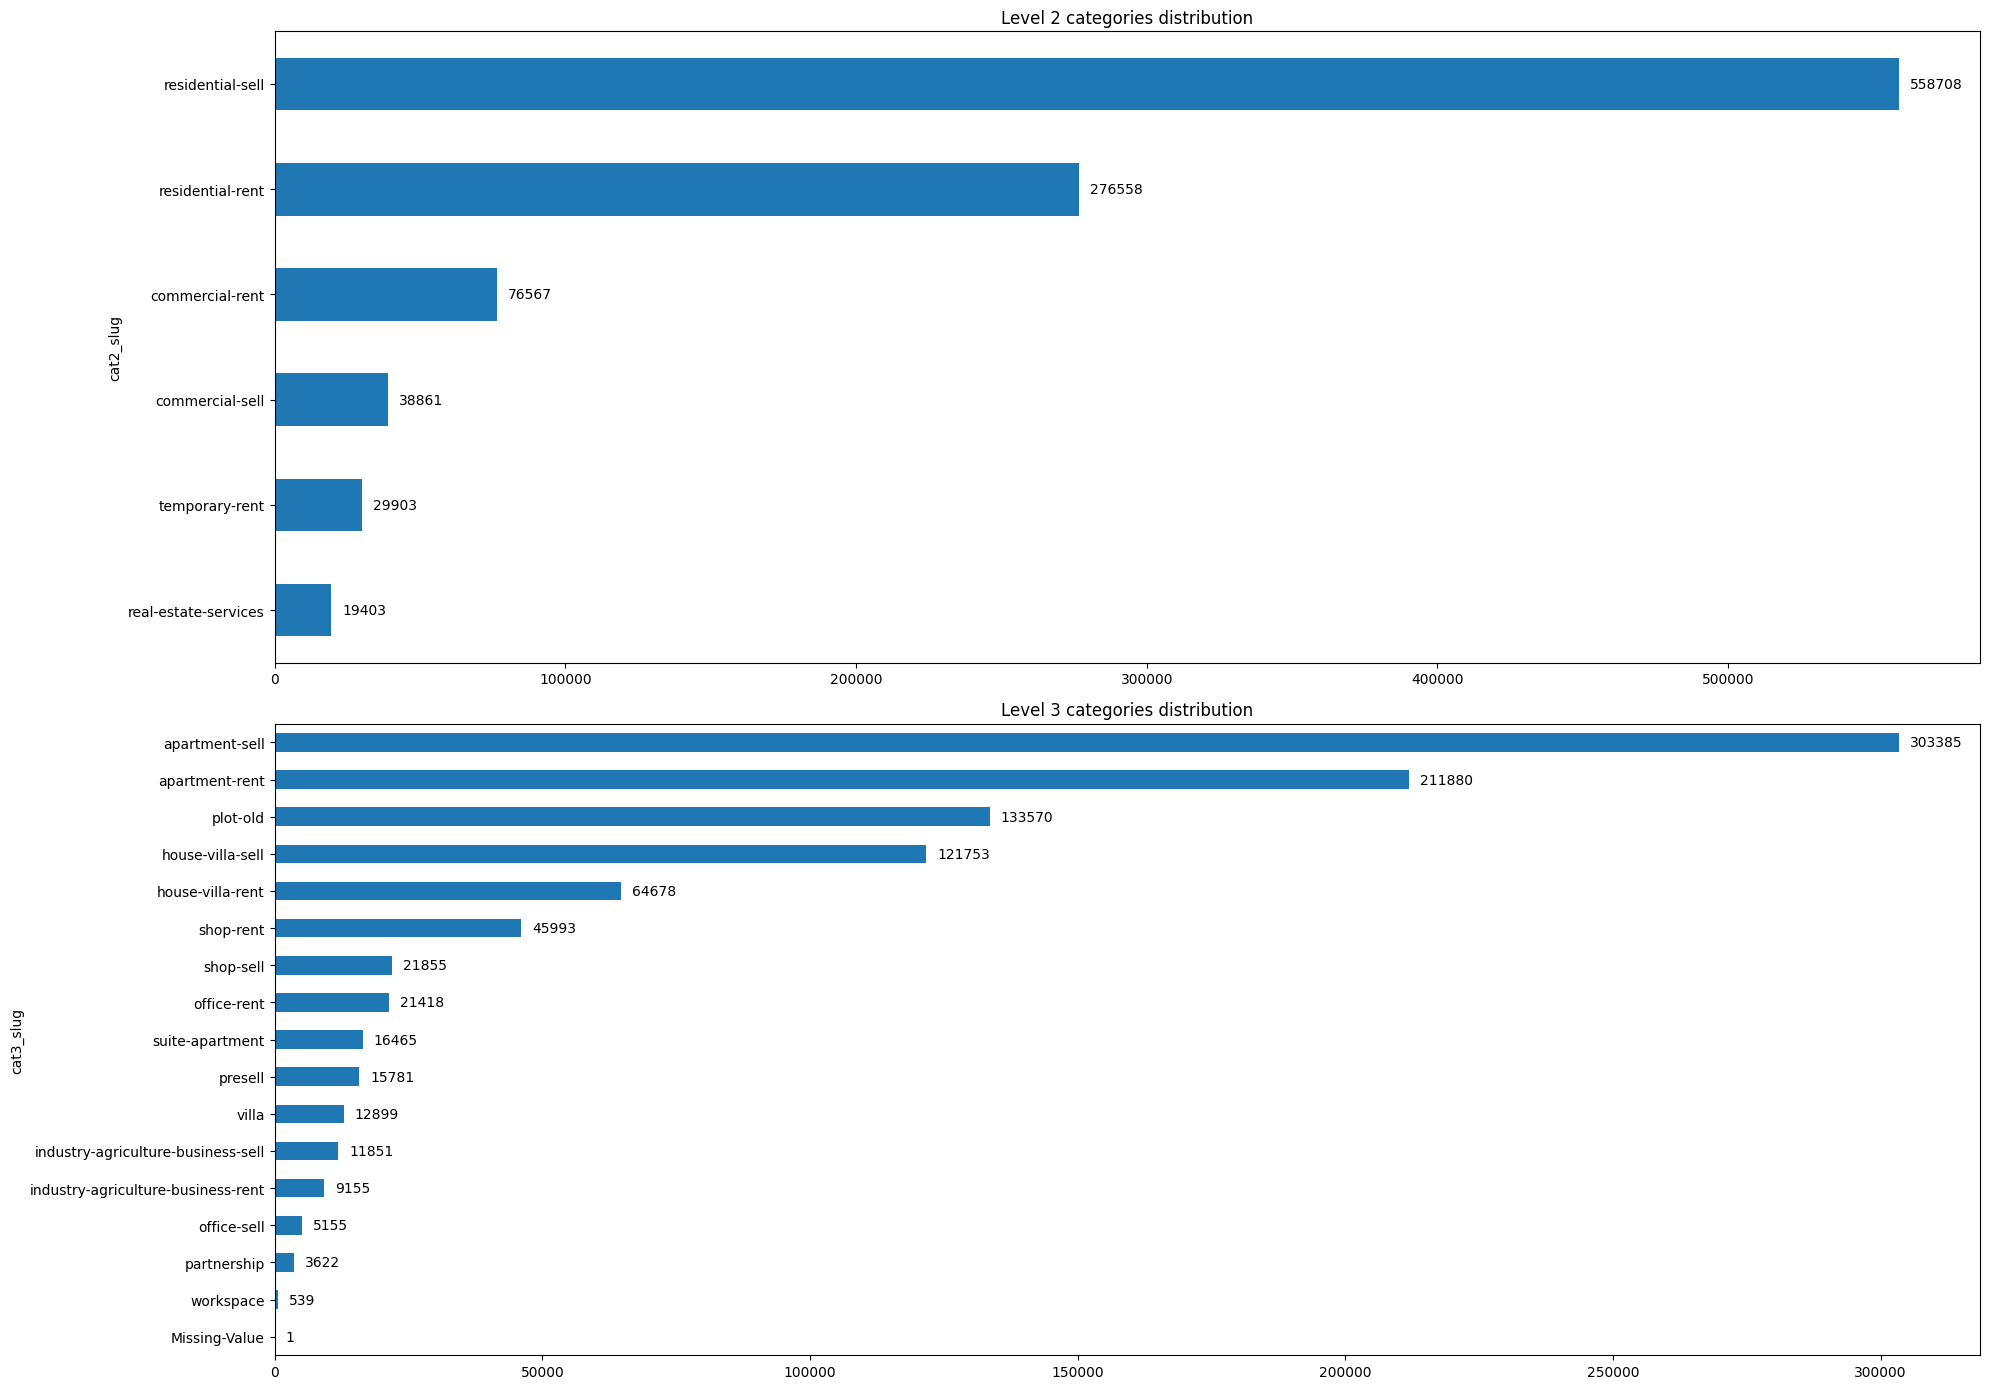

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(20, 14))
cat2_counts.plot.barh(ax=axes[0])
cat3_counts.plot.barh(ax=axes[1])
axes[0].set_title("Level 2 categories distribution")
axes[1].set_title("Level 3 categories distribution")
for i in axes:
    i.invert_yaxis()
    bar = i.containers[0]
    i.bar_label(bar, padding=8)
plt.tight_layout()
plt.show()

In [10]:
data["construction_year"].tail(40)

#plt.hist(data["construction_year"])

999960           ۱۴۰۰
999961           ۱۴۰۲
999962           ۱۳۹۸
999963           ۱۳۹۰
999964            NaN
999965            NaN
999966           ۱۳۹۲
999967           ۱۳۹۴
999968           ۱۳۹۶
999969           ۱۳۹۵
999970           ۱۳۹۳
999971           ۱۴۰۲
999972           ۱۳۸۹
999973           ۱۳۸۳
999974           ۱۳۹۲
999975            NaN
999976           ۱۴۰۰
999977            NaN
999978    قبل از ۱۳۷۰
999979           ۱۳۹۰
999980           ۱۳۹۱
999981           ۱۳۸۷
999982           ۱۳۹۶
999983            NaN
999984           ۱۳۷۲
999985           ۱۳۹۸
999986           ۱۴۰۳
999987           ۱۳۹۴
999988           ۱۴۰۳
999989           ۱۴۰۳
999990           ۱۴۰۱
999991           ۱۳۸۸
999992           ۱۴۰۱
999993           ۱۳۸۶
999994            NaN
999995           ۱۴۰۳
999996           ۱۴۰۳
999997    قبل از ۱۳۷۰
999998            NaN
999999           ۱۳۸۲
Name: construction_year, dtype: object

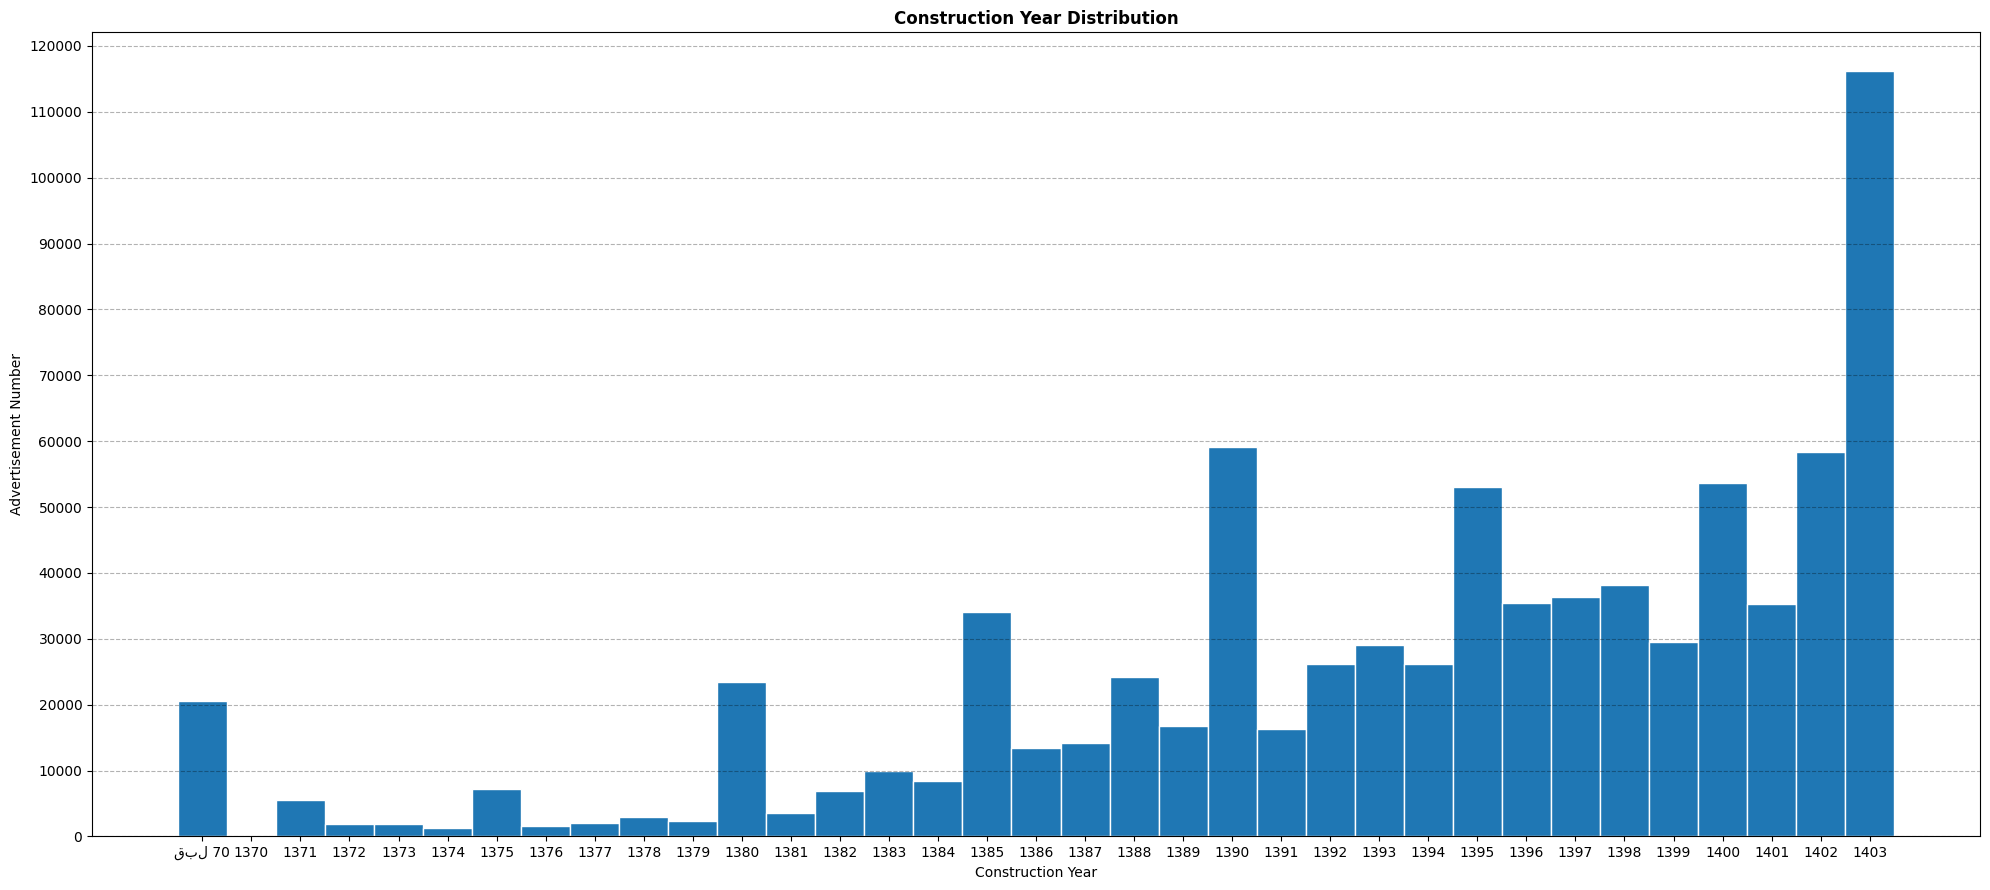

In [11]:
persian_to_english = str.maketrans(
    "۰۱۲۳۴۵۶۷۸۹",
    "0123456789"
)
before_1370 = data["construction_year"].eq("قبل از ۱۳۷۰")
construction_year = pd.to_numeric(data["construction_year"].str.translate(persian_to_english), errors="coerce")
temp = construction_year.copy()
temp.loc[before_1370] = 1369
valid_years = temp.dropna()
fig, ax = plt.subplots(figsize=(20, 9))
bins = np.arange(valid_years.min() - 0.5, valid_years.max() + 1.5, 1)
ax.hist(valid_years, bins=bins, edgecolor="white")
ax.set_title("Construction Year Distribution", fontweight="bold")
ax.set_xlabel("Construction Year")
ax.set_ylabel("Advertisement Number")
ax.set_xticks(range(1369, 1404, 1))
ax.set_xticklabels(["قبل 70"] + list(range(1370, 1404)))
ax.set_yticks(range(0, 121000, 10000))
ax.grid(axis="y", linestyle="--", alpha=0.3, color="black")
plt.tight_layout()
plt.show()

In [12]:
temp = data[["created_at_month", "cat2_slug"]].copy()
temp["month"] = pd.to_datetime(temp["created_at_month"])
temp["transaction"] = temp["cat2_slug"].str.split('-').str[-1].map({
                                                                    "sell": "Sell",
                                                                    "rent": "Rent"
                                                                })
monthly_counts = temp.dropna().groupby(["month", "transaction"]).size().unstack()
monthly_counts

transaction,Rent,Sell
month,,
2020-02-01,NaN,1.0
2020-12-01,1.0,NaN
2021-02-01,NaN,1.0
2021-05-01,NaN,1.0
2021-06-01,NaN,1.0
2021-11-01,NaN,1.0
2021-12-01,1.0,1.0
2022-01-01,NaN,1.0
2022-02-01,1.0,1.0


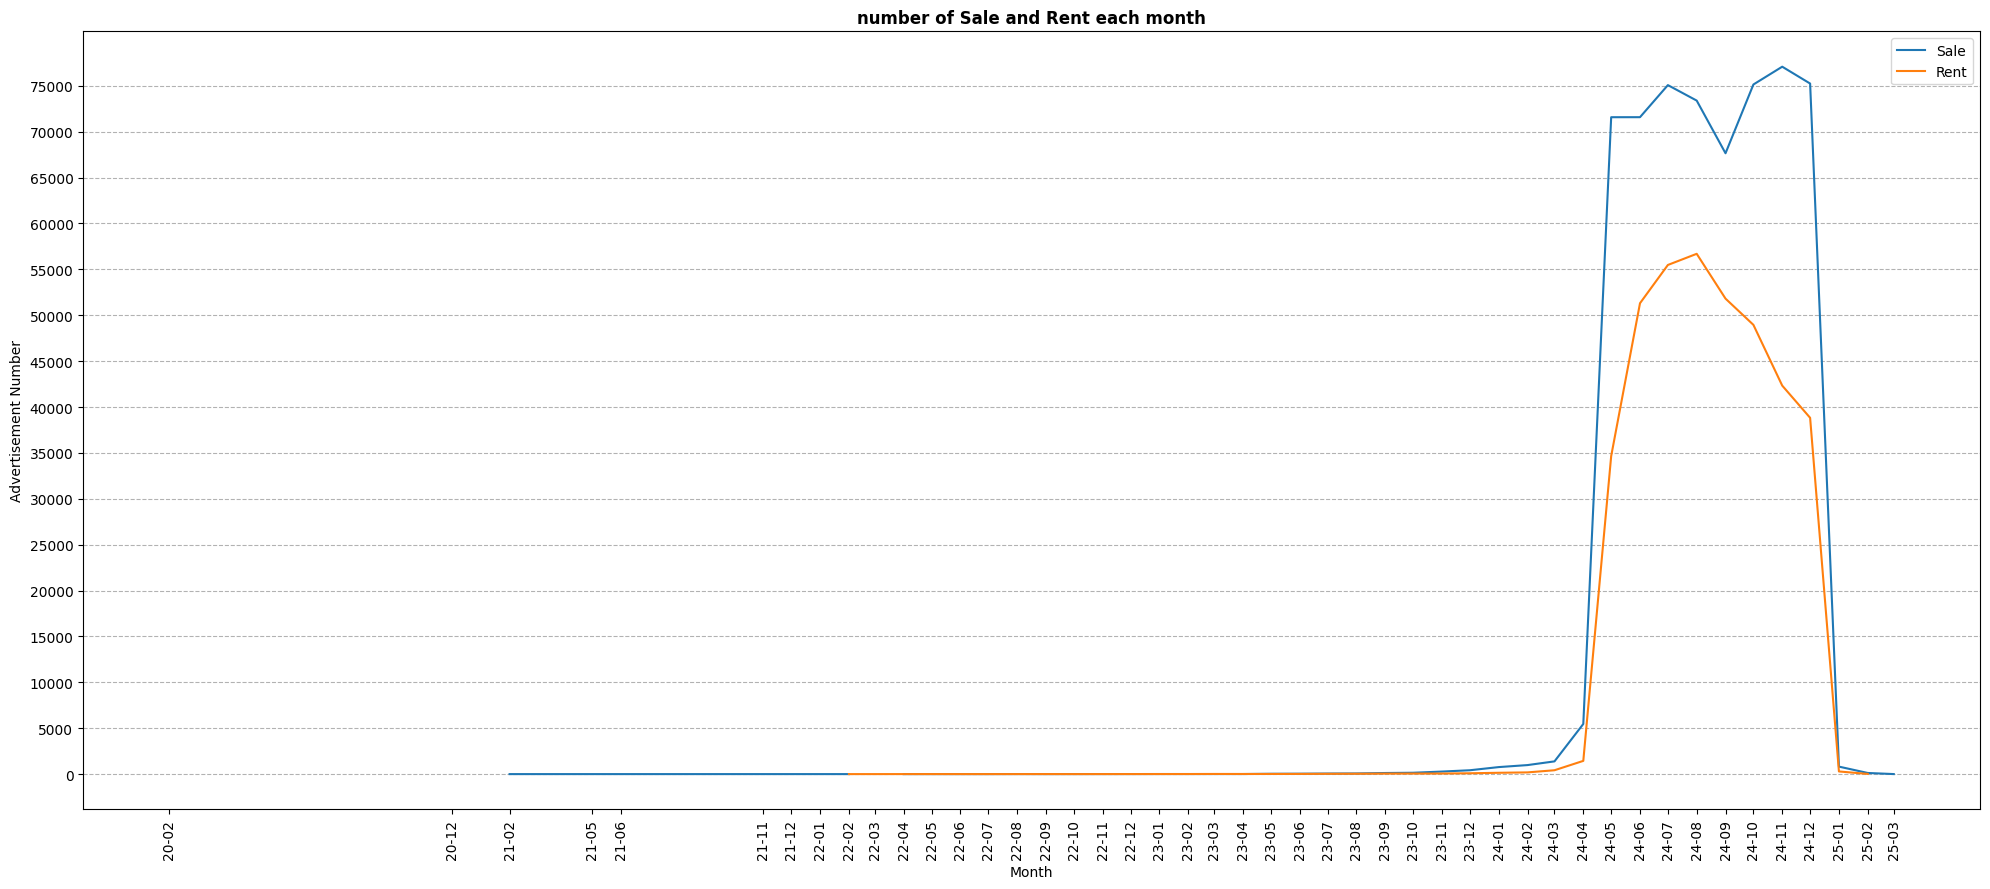

In [13]:
fig, ax = plt.subplots(figsize=(20, 9))
ax.plot(monthly_counts["Sell"], label="Sale")
ax.plot(monthly_counts["Rent"], label="Rent")
ax.set_title("number of Sale and Rent each month", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Advertisement Number")
ax.set_yticks(range(0, 80000, 5000))
ax.set_xticks(monthly_counts.index)
ax.set_xticklabels(monthly_counts.index.strftime("%y-%m"), rotation=90)
ax.grid(axis="y", linestyle="--", alpha=0.3, color="black")
ax.legend()
plt.tight_layout()
plt.show()

پلات بالا تمام سال ‌ها رو نمایش میده، اما حدود 99 درصد آگهی‌ ها متعلق به سال 2024 هستند

بنابراین افزایش شدید تعداد آگهی ‌ها را نمی‌توان با اطمینان رشد واقعی یا الگوی فصلی دانست چون دیگر سال ها دیتای درستی ندارن

تبدیل تاریخ وافعی نمیشه انجام داد چون روز ثبت شدن تمام آگهی ها برابر 1 هست و از این لحاظ  اشتباه میشه منتهی من صرفا ماه هارو به هم تبدیل میکنم 

در نهایت از دیتای سال های جز از سال 2024 در حد همون 2، 3 درصدی که وجود داره هم استفاده میکنم یعنی هر برای هر سال ماه هایی که دارای آگهی هستن رو جکع میکنم

در نهایت برای هرماه نشون میدم چقدر دیتا وجود داده و مجدد عرض کنم که دیتا به ماه های میلادی هست و فقط اسمش عوض شده نه تبدیل وافعی تاریخ

In [14]:
temp["month_number"] = temp["month"].dt.month
month_counts = temp.dropna(subset=["month_number", "transaction"]).groupby(["month_number", "transaction"]).size().unstack(fill_value=0)
month_counts

transaction,Rent,Sell
month_number,,
1,441,1593
2,217,1120
3,439,1398
4,1458,5476
5,34674,71621
6,51334,71631
7,55516,75142
8,56738,73470
9,51871,67773


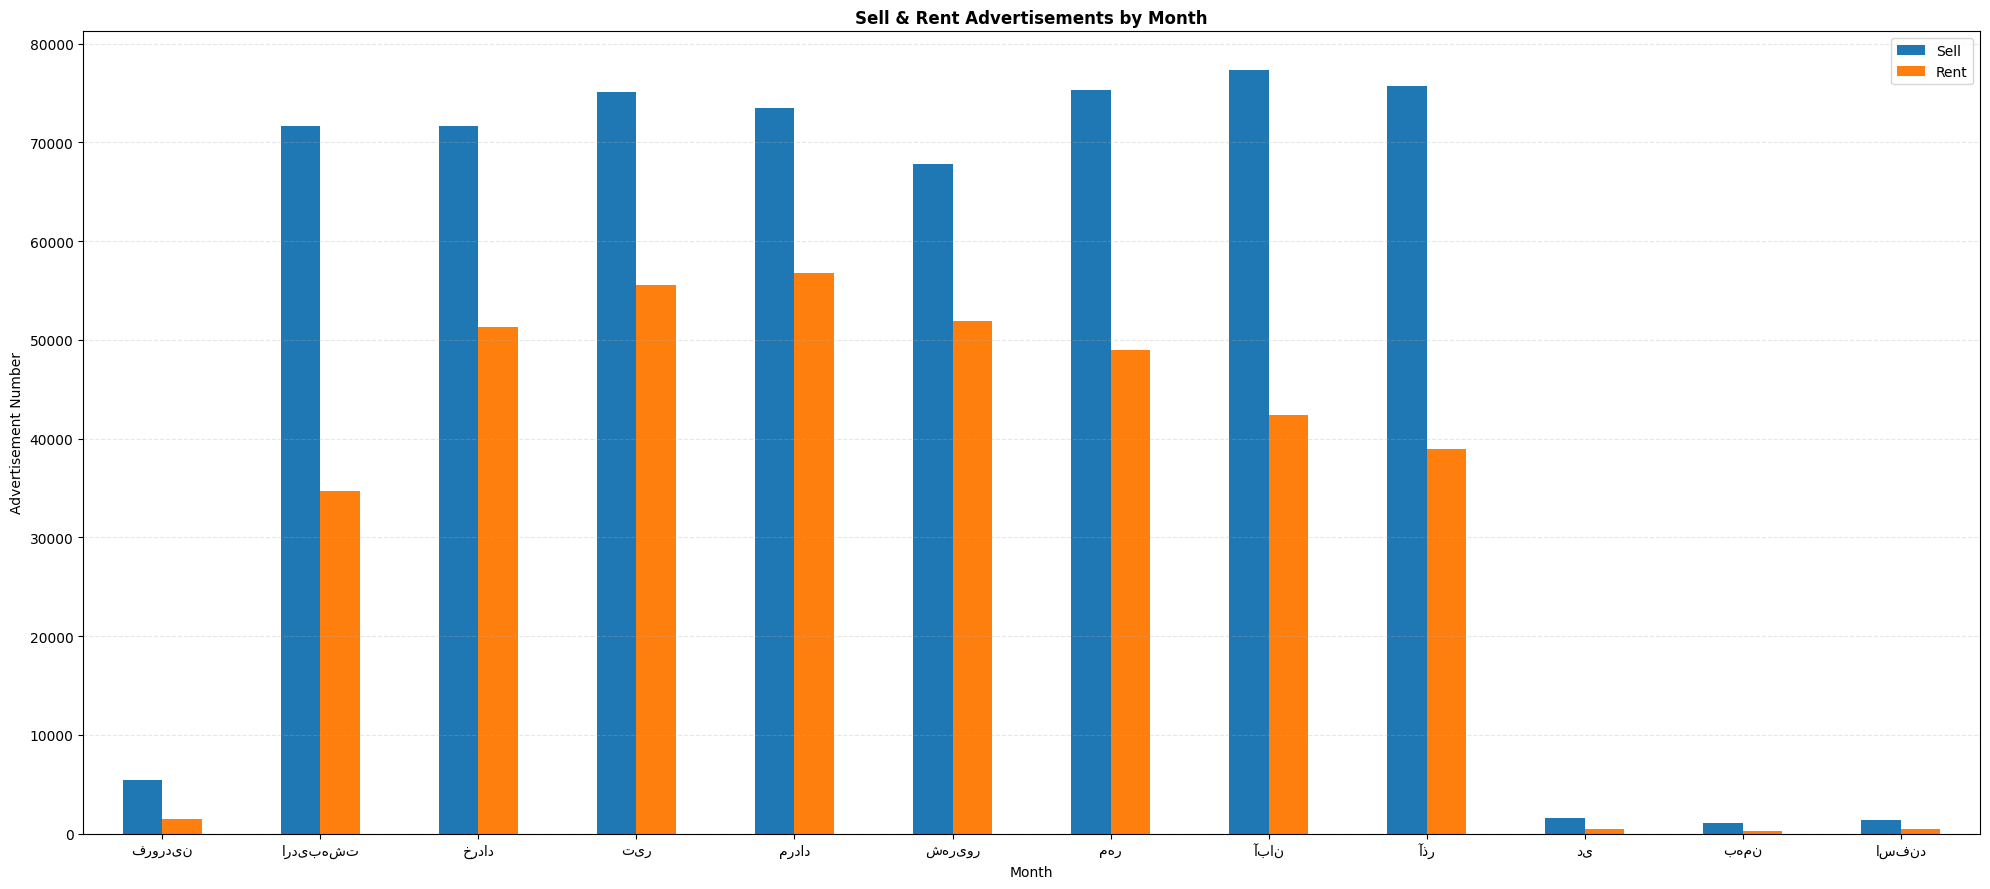

In [15]:
jalali_month_counts = month_counts.loc[[4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3]].copy()
jalali_month_counts.index = [
    "فروردین", "اردیبهشت", "خرداد",
    "تیر", "مرداد", "شهریور",
    "مهر", "آبان", "آذر",
    "دی", "بهمن", "اسفند"
]
fig, ax = plt.subplots(figsize=(20, 9))
jalali_month_counts[["Sell", "Rent"]].plot(kind="bar", ax=ax)
ax.set_title("Sell & Rent Advertisements by Month", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Advertisement Number")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

جهش ماه‌ های ابتدایی احتمالا ناشی از پوشش نامتوازن و احتمالا مشکل از سمت دیتای مرجع باشه و نمی‌توان آن را یک الگوی فصلی قطعی دانست

در ماه‌ های دارای دیتا کافی، آگهی‌ های اجاره تا مرداد افزایش یافته و سپس کاهش پیدا کرده‌اند یعنی انگار توی تابستون و تعطیلات اجاره ها بیشتر و رابطه مستقیم با سفر های مردم داره

 آگهی‌ های فروش نوسان کمتری داشته و نسبتا باثبات بودند

-----

Part 4

In [16]:
q4_data = data.loc[data["cat2_slug"].isin(["residential-sell", "commercial-sell"]), ["cat3_slug", "price_value"]].copy()
q4_data = q4_data.dropna()
q4_data["cat3_slug"].value_counts()

cat3_slug
apartment-sell                        303380
house-villa-sell                      121748
plot-old                              109836
shop-sell                              18559
industry-agriculture-business-sell      9088
office-sell                             4480
Name: count, dtype: int64

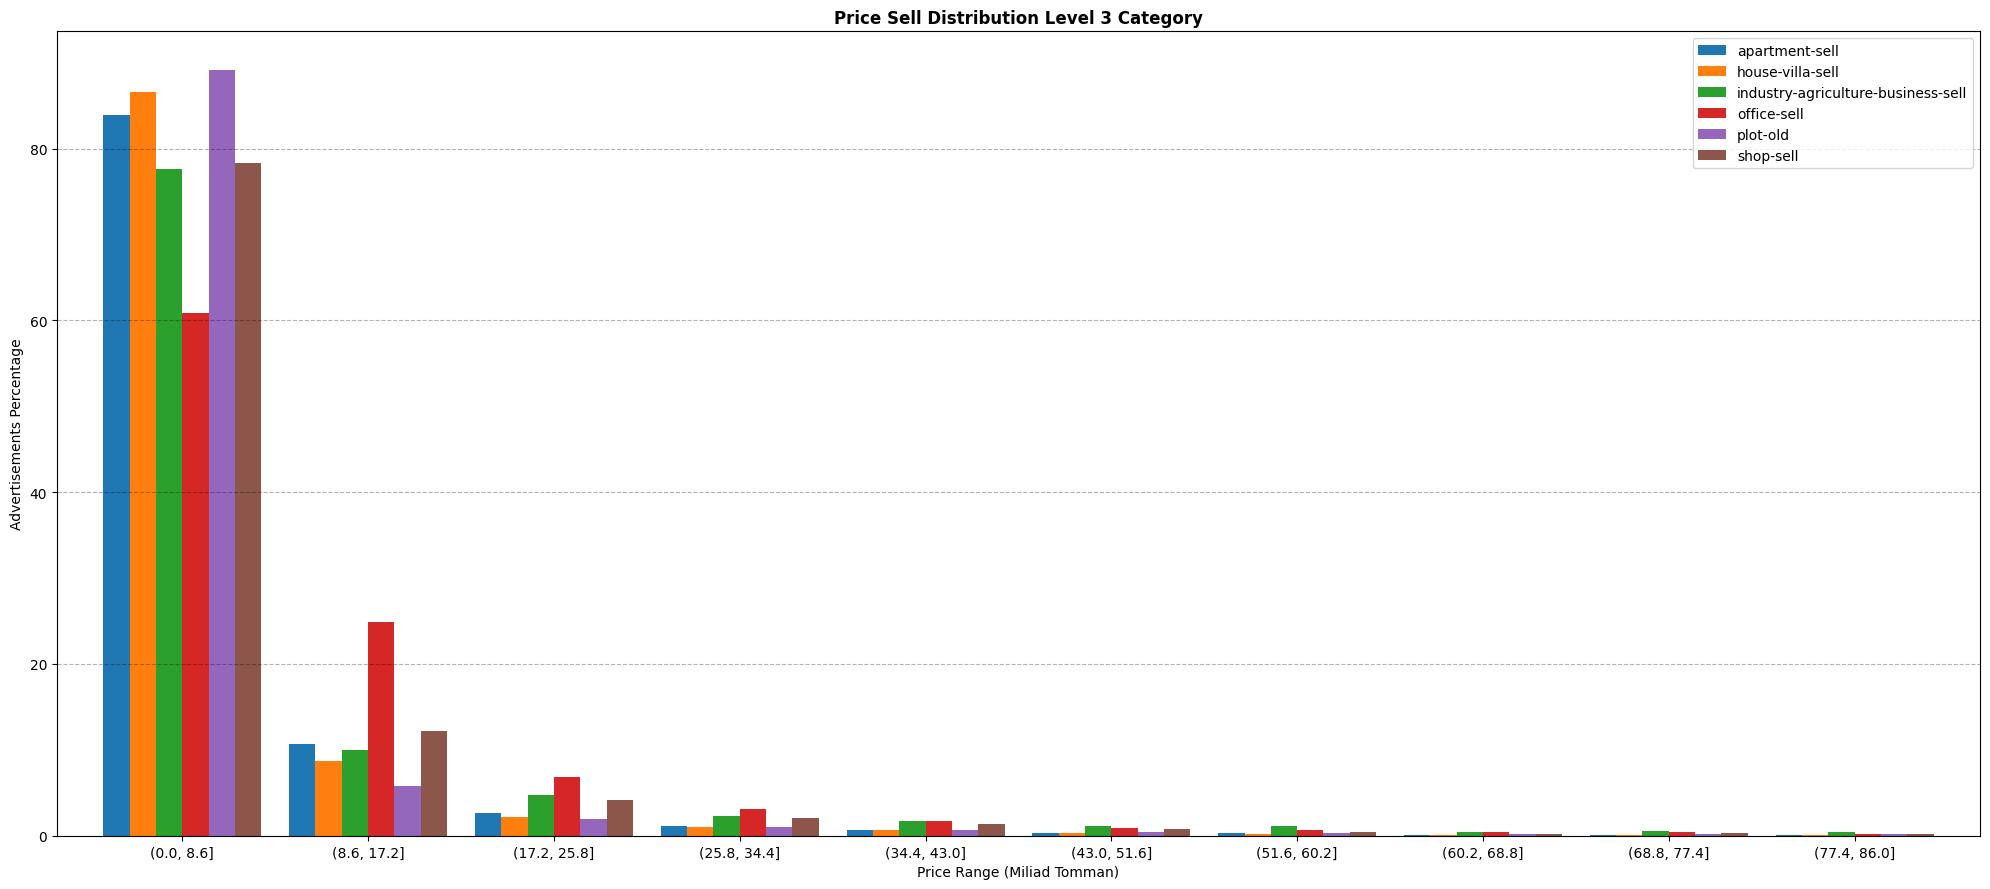

In [17]:
plot_data = q4_data[q4_data["price_value"] > 0].copy()
plot_data["price_billion"] = plot_data["price_value"] / 1000000000
upper_limit = plot_data["price_billion"].quantile(0.99)
plot_data = plot_data[plot_data["price_billion"] <= upper_limit]
bins = np.linspace(0, upper_limit, 11)
plot_data["price_range"] = pd.cut(plot_data["price_billion"], bins=bins)
price_distribution = (pd.crosstab(plot_data["price_range"],plot_data["cat3_slug"], normalize="columns") * 100)
ax = price_distribution.plot(kind="bar", figsize=(20, 9) ,width=0.85)
ax.set_title("Price Sell Distribution Level 3 Category", fontweight="bold")
ax.set_xlabel("Price Range (Miliad Tomman)")
ax.set_ylabel("Advertisements Percentage")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3, color="black")
ax.legend()
plt.tight_layout()
plt.show()

------

آزمون فرض

In [18]:
from scipy import stats

In [19]:
city_types = pd.read_csv("iran_city_classification.csv")
print(city_types)
city_types["دسته‌بندی"].value_counts()

             نام شهر دسته‌بندی
0              karaj  کلان‌شهر
1             tehran  کلان‌شهر
2            mashhad  کلان‌شهر
3              ahvaz  کلان‌شهر
4         kermanshah  کلان‌شهر
..               ...       ...
235            baneh  شهر کوچک
236  ahmadsar-gourab  شهر کوچک
237           saqqez  شهر کوچک
238           mianeh  شهر کوچک
239       lavandevil  شهر کوچک

[240 rows x 2 columns]


دسته‌بندی
شهر کوچک    231
کلان‌شهر      9
Name: count, dtype: int64

In [20]:
city_types = city_types.rename(columns={
                    "نام شهر": "city_slug",
                    "دسته‌بندی": "type"
                })

In [21]:
maskooni_advertisement = data.loc[data["cat2_slug"].isin(["residential-sell", "residential-rent"]), ["city_slug", "building_size"]].copy()
maskooni_advertisement

,city_slug,building_size
1,tehran,60.0
2,tehran,132.0
4,mashhad,115.0
5,ahvaz,100.0
7,tehran,100.0
...,...,...
999993,mashhad,50.0
999995,kermanshah,180.0
999996,tehran,110.0
999997,yazd,200.0


In [22]:
hypothesis_data = maskooni_advertisement.merge(city_types, on="city_slug")
hypothesis_data.head(10)

,city_slug,building_size,type
0,tehran,60.0,کلان‌شهر
1,tehran,132.0,کلان‌شهر
2,mashhad,115.0,کلان‌شهر
3,ahvaz,100.0,کلان‌شهر
4,tehran,100.0,کلان‌شهر
5,mahdasht-city,78.0,شهر کوچک
6,mashhad,80.0,کلان‌شهر
7,pardis-city,87.0,شهر کوچک
8,tehran,91.0,کلان‌شهر
9,mashhad,169.0,کلان‌شهر


In [23]:
print(len(hypothesis_data))
hypothesis_data.dropna(inplace=True)
len(hypothesis_data)

805075


805024

In [24]:
lower = hypothesis_data["building_size"].quantile(0.01)
upper = hypothesis_data["building_size"].quantile(0.99)
filtered_data = hypothesis_data[hypothesis_data["building_size"].between(lower, upper)]
big_city = filtered_data.loc[filtered_data["type"] == "کلان‌شهر", "building_size"]
small_city = filtered_data.loc[filtered_data["type"] == "شهر کوچک", "building_size"]
print("Big-city median:", big_city.median())
print("Small-city median:", small_city.median())

Big-city median: 100.0
Small-city median: 110.0


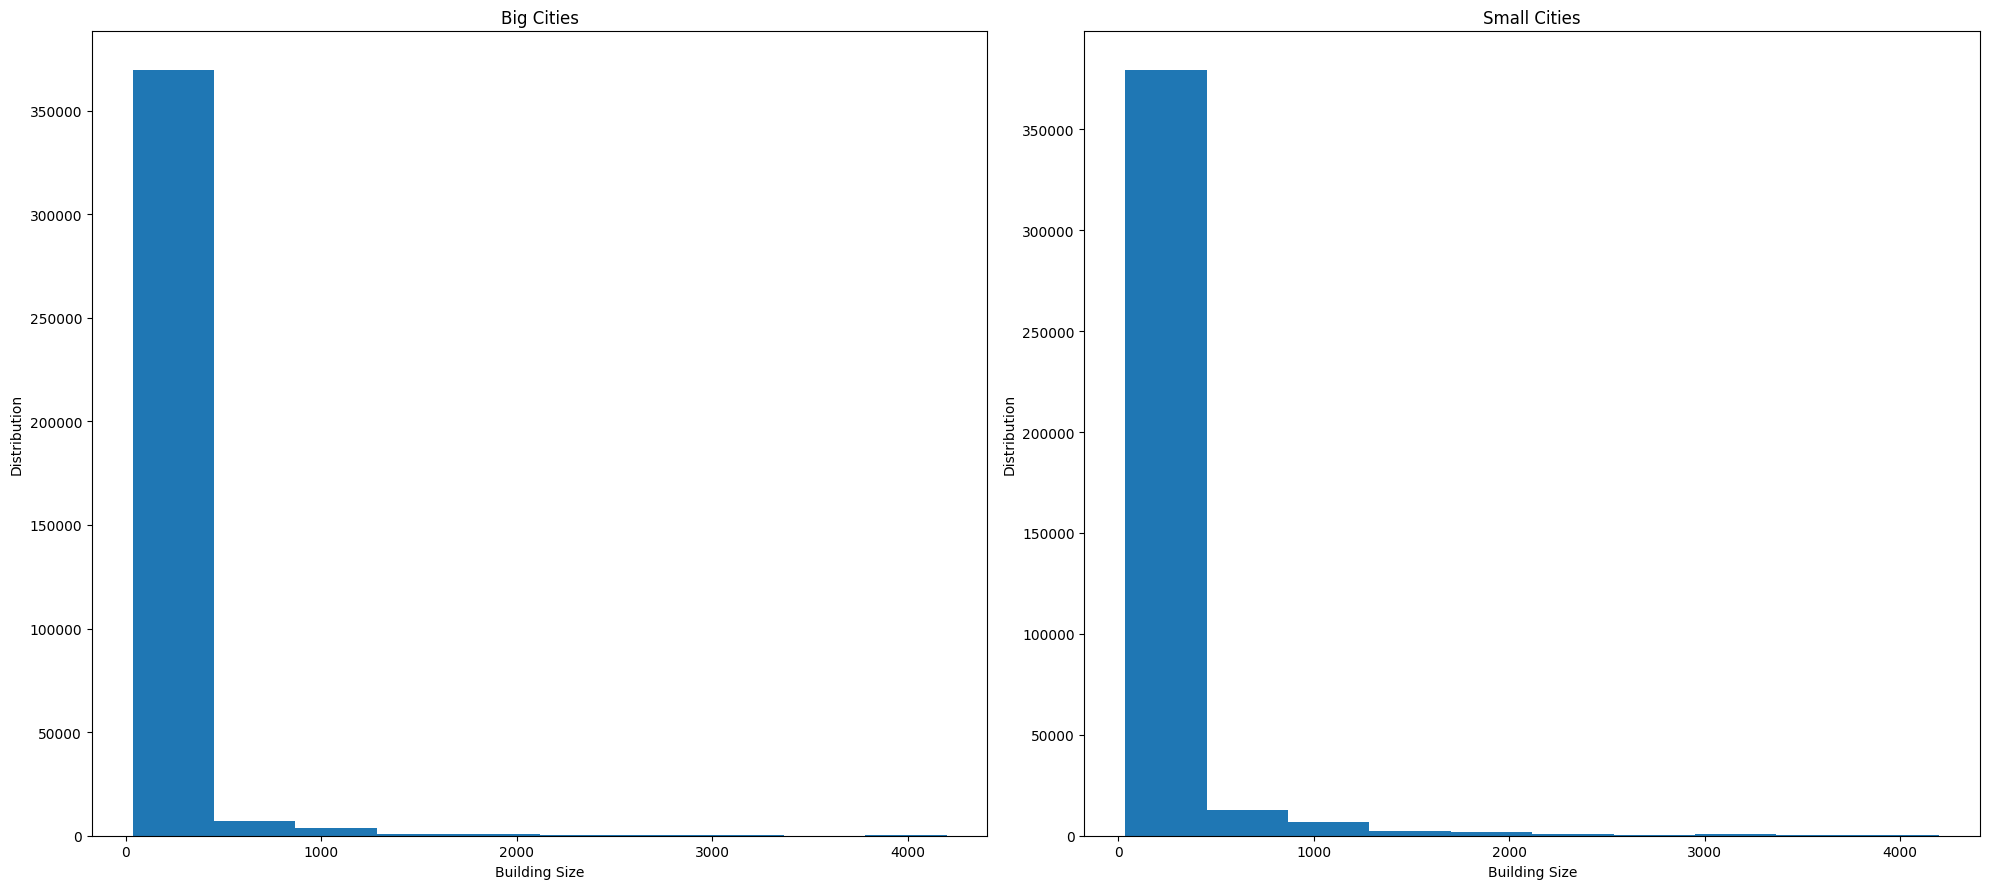

In [25]:
limit = hypothesis_data["building_size"].quantile(0.99)
fig, ax = plt.subplots(1, 2, figsize=(20, 9))
ax[0].hist(big_city[big_city <= limit])
ax[0].set_title("Big Cities")
ax[0].set_xlabel("Building Size")
ax[0].set_ylabel("Distribution")
ax[1].hist(small_city[small_city <= limit])
ax[1].set_title("Small Cities")
ax[1].set_xlabel("Building Size")
ax[1].set_ylabel("Distribution")
plt.tight_layout()
plt.show()

آزمون شاپیرو به علت جواب دادن روی داده هایی با کمتر از 5000 سطر رد میشود و نمیتوان استفاده کرد

هر دو داده عددی و مقایسه میانگین هست پس آزمون تی تست تو سمپل گزینه مناسبی ست ولی چون توزیع داده ها نرمال نیست به سراغ آزمون معادل نان پارامتریک آن یعنی من ویتنی میرویم

In [26]:
alpha = 0.05
# step1 ---> miu(big_city_building_size) < miu(small_city_building_size) 
# step2 ---> miu(big_city_building_size) >= miu(small_city_building_size)
# step3 ---> H0: miu(big_city_building_size) >= miu(small_city_building_size)
# step3 ---> H1(alternative): miu(big_city_building_size) < miu(small_city_building_size)
u_stat, p_value = stats.mannwhitneyu(big_city, small_city, alternative="less")
print("H0: building size in big cities not smaller(more or equal) than small cities")
print("H1: building size in big cities smaller than small cities")
print(f"p-value: {p_value:.30f}")
print("Reject H0(in this question claim not rejected)" if p_value < alpha else "Fail to reject H0(n this question claim also rejected)")

H0: building size in big cities not smaller(more or equal) than small cities
H1: building size in big cities smaller than small cities
p-value: 0.000000000000000000000000000000
Reject H0(in this question claim not rejected)


با توجه به اینکه مقدار 
p-value
از آلفا(سطح معناداری) کمتر شده فرض صفر رد میشود پس شواهد کافی برای رد ادعا نداریم
پس میتوان گفت مساحت خانه های مسکونی در کلان شهرا تمایل دارد کمتر از مساحت خانه ها در شهر های کوچک باشد

In [27]:
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from IPython.display import display

# حذف داده‌های فاقد مختصات جغرافیایی
df_map = data.dropna(subset=['location_latitude', 'location_longitude']).copy()

# تبدیل دیتافریم پانداس به ژئودیتافریم (GeoDataFrame)
gdf_all = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map['location_longitude'], df_map['location_latitude']),
    crs="EPSG:4326"
)

# دریافت نقشه مرزهای جهان  
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(url)

# استخراج مرز دقیق کشور ایران
iran_border = world[world['name'] == 'Iran']

# اگهی های که داخل ایران هستند را فیلتر می‌کنیم
gdf = gpd.sjoin(gdf_all, iran_border, predicate='within')

# گرد کردن مختصات جغرافیایی برای گروه‌بندی
df_map['lat_rounded'] = df_map['location_latitude'].round(2)
df_map['lon_rounded'] = df_map['location_longitude'].round(2)

# گروه‌بندی بر اساس مختصات گرد شده و شمارش تعداد آگهی‌های هر محدوده
density_counts = df_map.groupby(['lat_rounded', 'lon_rounded']).size().reset_index(name='ad_count')

# مرتب‌سازی برای یافتن منطقه‌ای با بیشترین آگهی
top_area = density_counts.sort_values(by='ad_count', ascending=False).iloc[0]

print("پرتراکم‌ترین محدوده جغرافیایی :")
print(f"عرض جغرافیایی : {top_area['lat_rounded']}")
print(f"طول جغرافیایی : {top_area['lon_rounded']}")
print(f"تعداد آگهی در این محدوده : {int(top_area['ad_count'])} آگهی")

# محاسبه مرکز نقشه
lat_center = gdf.geometry.y.mean()
lon_center = gdf.geometry.x.mean()

# ایجاد نقشه پایه 
m = folium.Map(location=[lat_center, lon_center], zoom_start=6)

# استخراج مختصات برای هیت‌مپ
heat_data = [[geom.y, geom.x] for geom in gdf.geometry]

# افزودن لایه هیت‌مپ
HeatMap(heat_data, radius=12, blur=8, min_opacity=0.3).add_to(m)

# قرار دادن فلش روی شلوغ‌ترین نقطه
top_lat = top_area['lat_rounded']
top_lon = top_area['lon_rounded']
count = int(top_area['ad_count'])

# قرار دادن فلش روی نقشه با استفاده از ایکون
folium.Marker(
    location=[top_lat, top_lon],
    tooltip=f"پرتراکم‌ترین منطقه با {count} آگهی",
    icon=folium.Icon(color='red', icon='arrow-down', prefix='fa')
).add_to(m)

# ذخیره نقشه
m.save("heatmap.html")

پرتراکم‌ترین محدوده جغرافیایی :
عرض جغرافیایی : 35.68
طول جغرافیایی : 51.02
تعداد آگهی در این محدوده : 4654 آگهی


In [28]:
%pip install jdatetime arabic_reshaper python-bidi

Note: you may need to restart the kernel to use updated packages.


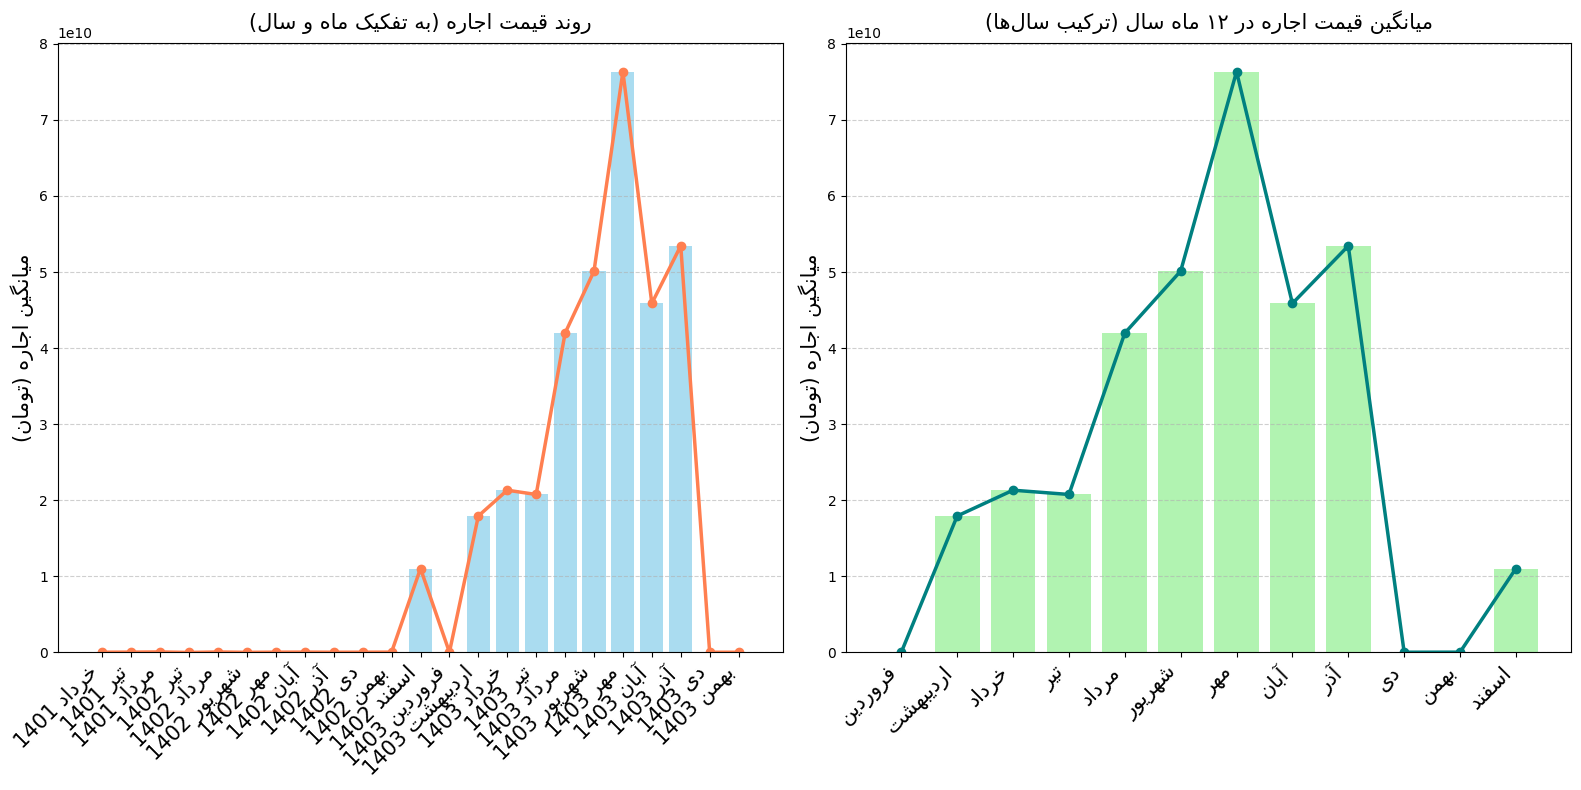

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import jdatetime
import arabic_reshaper
from bidi.algorithm import get_display

# تابع اصلاح فونت فارسی
def render_farsi(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# پاکسازی داده‌های خالی و تبدیل به دیتای زمان
df_rent = data.dropna(subset=['rent_value', 'created_at_month']).copy()
df_rent['created_at_month'] = pd.to_datetime(df_rent['created_at_month'])

# تابع جامع برای استخراج تمامی اطلاعات شمسی مورد نیاز در یک مرحله
def extract_shamsi_info(date_obj):
    sh_date = jdatetime.date.fromgregorian(date=date_obj.date())
    months = ['فروردین', 'اردیبهشت', 'خرداد', 'تیر', 'مرداد', 'شهریور',
              'مهر', 'آبان', 'آذر', 'دی', 'بهمن', 'اسفند']
    
    month_name = months[sh_date.month - 1]
    
    # برای نمودار اول (با سال)
    full_sort_key = f"{sh_date.year}-{sh_date.month:02d}"
    full_label = f"{month_name} {sh_date.year}"
    
    # برای نمودار دوم (فقط ماه)
    month_num = sh_date.month
    
    return pd.Series([full_sort_key, full_label, month_num, month_name])

# اعمال تابع روی دیتافریم
df_rent[['full_sort', 'full_label', 'month_num', 'month_name']] = df_rent['created_at_month'].apply(extract_shamsi_info)

# محاسبه میانگین‌ها برای هر دو حالت
# حالت اول: تفکیک بر اساس ماه و سال
trend_full = df_rent.groupby(['full_sort', 'full_label'])['rent_value'].mean().reset_index().sort_values('full_sort')

# حالت دوم: ترکیب سال‌ها در ۱۲ ماه
trend_monthly = df_rent.groupby(['month_num', 'month_name'])['rent_value'].mean().reset_index().sort_values('month_num')

# رسم نمودارها در کنار هم
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) # عرض 16 و ارتفاع 8 اینچ

# نمودار سمت چپ : روند قیمت اجاره (به تفکیک ماه و سال)
axes[0].bar(trend_full['full_label'], trend_full['rent_value'], color='skyblue', alpha=0.7)
axes[0].plot(trend_full['full_label'], trend_full['rent_value'], marker='o', linewidth=2.5, color='coral')

axes[0].set_title(render_farsi('روند قیمت اجاره (به تفکیک ماه و سال)'), fontsize=15, pad=10)
axes[0].set_ylabel(render_farsi('میانگین اجاره (تومان)'), fontsize=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# تنظیمات متن محور x نمودار اول
farsi_full_labels = [render_farsi(lbl) for lbl in trend_full['full_label']]
axes[0].set_xticks(range(len(farsi_full_labels)))
axes[0].set_xticklabels(farsi_full_labels, rotation=45, ha='right', fontsize=15)


# نمودار سمت راست : میانگین قیمت اجاره در ۱۲ ماه سال (ترکیب سال‌ها)
axes[1].bar(trend_monthly['month_name'], trend_monthly['rent_value'], color='lightgreen', alpha=0.7)
axes[1].plot(trend_monthly['month_name'], trend_monthly['rent_value'], marker='o', linewidth=2.5, color='teal')

axes[1].set_title(render_farsi('میانگین قیمت اجاره در ۱۲ ماه سال (ترکیب سال‌ها)'), fontsize=15, pad=10)
axes[1].set_ylabel(render_farsi('میانگین اجاره (تومان)'), fontsize=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# تنظیمات متن محور x نمودار دوم
farsi_month_labels = [render_farsi(lbl) for lbl in trend_monthly['month_name']]
axes[1].set_xticks(range(len(farsi_month_labels)))
axes[1].set_xticklabels(farsi_month_labels, rotation=45, ha='right', fontsize=15)

# تنظیم فاصله‌ها و نمایش
plt.tight_layout()
plt.show()

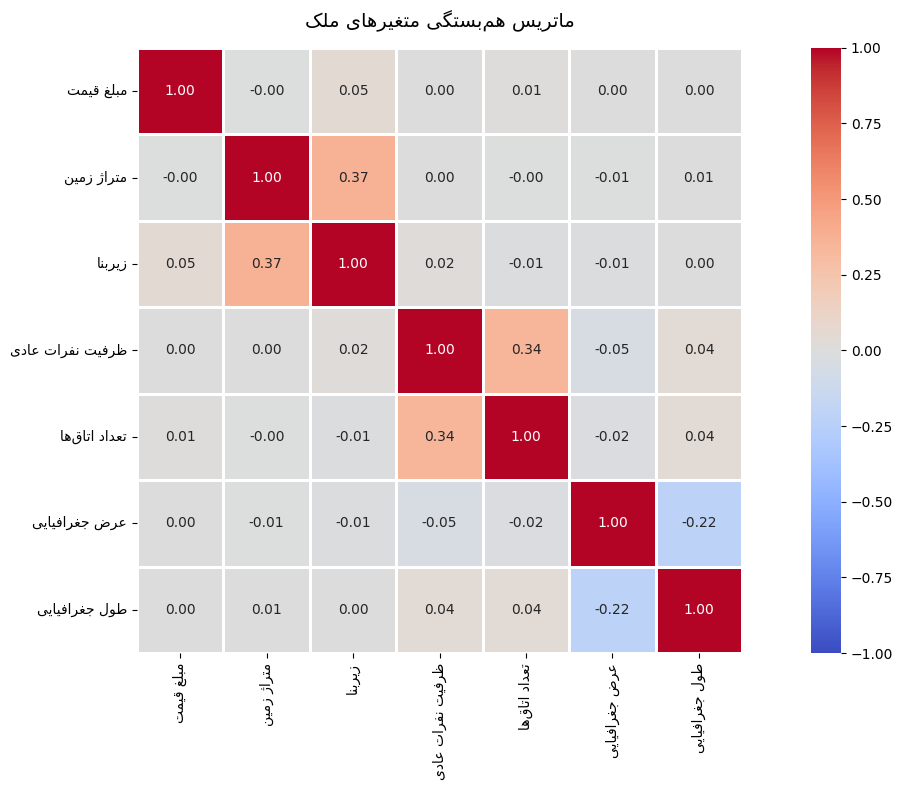

In [30]:
import seaborn as sns

def farsi(text):
    return get_display(arabic_reshaper.reshape(text))

# ستون‌های مورد نظر برای بررسی هم‌بستگی
target_columns = [
    'price_value',          # مبلغ قیمت
    'land_size',            # متراژ زمین
    'building_size',        # زیربنا
    'regular_person_capacity',    # ظرفیت نفرات عادی
    'rooms_count',                # تعداد اتاق‌ها
    'location_latitude',    # عرض جغرافیایی
    'location_longitude'   # طول جغرافیایی
]

# نوشتن نام انگلیسی ستون‌ها بر حسب فارسی
label_mapping = {
    'price_value': farsi('مبلغ قیمت'),
    'land_size': farsi('متراژ زمین'),
    'building_size': farsi('زیربنا'),
    'regular_person_capacity': farsi('ظرفیت نفرات عادی'),
    'rooms_count': farsi('تعداد اتاق‌ها'),
    'location_latitude': farsi('عرض جغرافیایی'),
    'location_longitude': farsi('طول جغرافیایی')
}

# اصلاح دیتا فریم تعداد اتاق
rooms_mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}

#  اعمال اصلاح
data['rooms_count'] = data['rooms_count'].map(rooms_mapping)

# تبدیل ستون‌ها به مقادیر عددی (برای جلوگیری از ارور نوع داده)
df_corr = data[target_columns].apply(pd.to_numeric, errors='coerce')

# محاسبه ماتریس هم‌بستگی پیرسون
corr_matrix = df_corr.corr()

# صفر کردن اونایی که nan هستند در نمودار
corr_matrix = corr_matrix.fillna(0) 

# تغییر نام سطرها و ستون‌ها به فارسی برای نمایش روی نمودار
corr_matrix.rename(index=label_mapping, columns=label_mapping, inplace=True)

# تنظیمات اندازه و رسم هیت‌مپ
plt.figure(figsize=(14, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,           # نمایش ضریب هم‌بستگی داخل خانه‌ها
    fmt='.2f',            # ۲ رقم اعشار
    cmap='coolwarm',      # طیف رنگی گرم و سرد (-۱ تا +۱)
    vmin=-1, vmax=1,      # محدوده‌بندی دامنه هم‌بستگی
    linewidths=0.8,
    square=True
)

plt.title(farsi('ماتریس هم‌بستگی متغیرهای ملک'), fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Amarehaye towsifi:
                          count    mean    std   min   25%    50%    75%  \
group_en                                                                   
Ghadimi (Ghabl az 96)  394448.0  108.75  90.44  20.0  65.0   85.0  120.0   
Jadid (96 va bad)      388125.0  128.77  99.43  20.0  80.0  105.0  145.0   

                          max  
group_en                       
Ghadimi (Ghabl az 96)  1000.0  
Jadid (96 va bad)      1000.0  

 Azmoone normal boodan (Shapiro-Wilk):
   Khanehaye ghadimi: p-value = 0.0000
   Khanehaye jadid: p-value = 0.0000

 Azmoon-e barabariye variansha (Levene): p-value = 0.0000

Pishfarze normal boodan rad shod. Estefade az azmoone naparametrice Mann-Whitney U.
   Amareye U: 58998549577.5000
   Meghdare p-value (yek-damane): 1.0000e+00

📌 Natijegiriye azmoone farz:
Farziyeye sefr (H0) rad nemishavad.
Tafsir: Shavahede amariye kafi baraye esbate bozorgtar boodane miangine metrazhe banaye khanehaye ghadimi nesbat be khanehaye jadid vojood nadarad

C:\Users\Poori\AppData\Local\Temp\ipykernel_9080\2923945437.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group_fa', y='building_size', data=df_plot, palette='Set2',


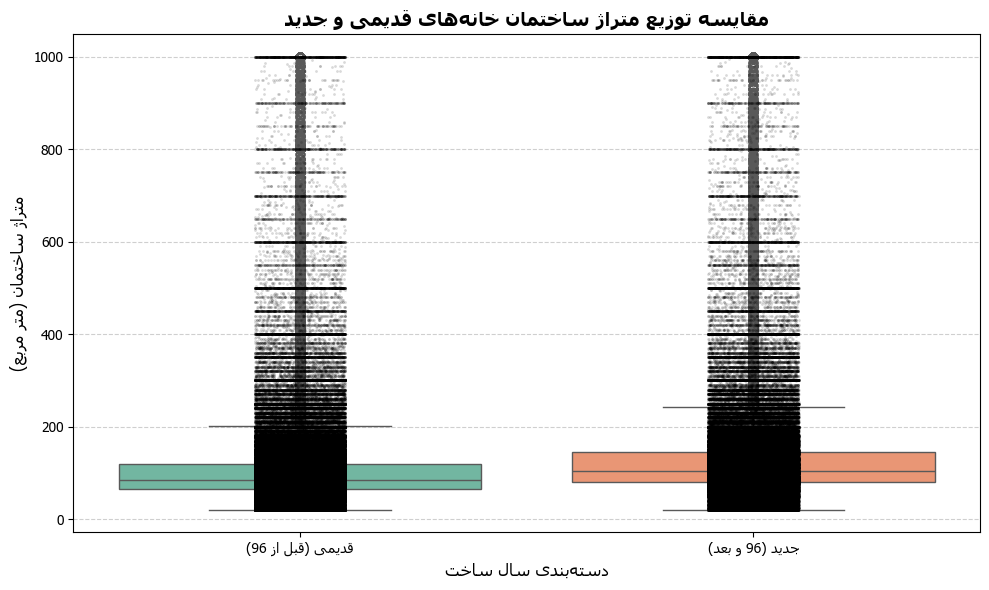

In [31]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import arabic_reshaper
from bidi.algorithm import get_display

font_path = r'C:\Windows\Fonts\tahoma.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

df = pd.read_csv('divar.csv', low_memory=False)

FA2EN = str.maketrans('۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩', '01234567890123456789')
def to_number(col):
    s = df[col].astype(str).str.translate(FA2EN)
    s = s.str.extract(r'(-?\d+(?:\.\d+)?)', expand=False)
    return pd.to_numeric(s, errors='coerce')

df['building_size'] = to_number('building_size')
df['construction_year'] = to_number('construction_year')

df = df[df['building_size'].notna() & df['construction_year'].notna()]
df = df[df['building_size'].between(20, 1000)]
df = df[df['construction_year'].between(1300, 1405)]

df['group_en'] = np.where(df['construction_year'] < 1396, 'Ghadimi (Ghabl az 96)', 'Jadid (96 va bad)')

old_sizes = df[df['group_en'] == 'Ghadimi (Ghabl az 96)']['building_size']
new_sizes = df[df['group_en'] == 'Jadid (96 va bad)']['building_size']

print("Amarehaye towsifi:")
print(df.groupby('group_en')['building_size'].describe().round(2))

# Barresiye pishfarzhaye azmoone parametric
stat_old, p_old = stats.shapiro(old_sizes.sample(min(5000, len(old_sizes)), random_state=42))
stat_new, p_new = stats.shapiro(new_sizes.sample(min(5000, len(new_sizes)), random_state=42))
print(f"\n Azmoone normal boodan (Shapiro-Wilk):")
print(f"   Khanehaye ghadimi: p-value = {p_old:.4f}")
print(f"   Khanehaye jadid: p-value = {p_new:.4f}")

levene_stat, levene_p = stats.levene(old_sizes, new_sizes)
print(f"\n Azmoon-e barabariye variansha (Levene): p-value = {levene_p:.4f}")

# Anjame azmoone farz
is_normal = (p_old > 0.05) and (p_new > 0.05)

print("\n" + "="*50)
if is_normal:
    print("Pishfarze normal boodan bargharar ast. Estefade az azmoone t_e mostaghel (Welch).")
    t_stat, p_value_two_tailed = stats.ttest_ind(old_sizes, new_sizes, equal_var=False)

    mean_old = old_sizes.mean()
    mean_new = new_sizes.mean()

    if mean_old > mean_new:
        p_value_final = p_value_two_tailed / 2
    else:
        p_value_final = 1 - (p_value_two_tailed / 2)

    print(f"   Amareye t: {t_stat:.4f}")
    print(f"   Meghdar-e p-value (yek-damane): {p_value_final:.4e}")
else:
    print("Pishfarze normal boodan rad shod. Estefade az azmoone naparametrice Mann-Whitney U.")
    u_stat, p_value_final = stats.mannwhitneyu(old_sizes, new_sizes, alternative='greater')
    print(f"   Amareye U: {u_stat:.4f}")
    print(f"   Meghdare p-value (yek-damane): {p_value_final:.4e}")

# Natijegiriye nahaee
alpha = 0.05
print("\n" + "="*50)
print("📌 Natijegiriye azmoone farz:")
if p_value_final < alpha:
    print("Farziyeye sefr (H0) rad mishavad.")
    print("Tafsir: Shavahede amariye kafi vojood darad ke miangine metrazhe banaye khanehaye ghadimi-sakht (ghabl az 96) betowre manadari bishtar az khanehaye jadid-sakht ast.")
else:
    print("Farziyeye sefr (H0) rad nemishavad.")
    print("Tafsir: Shavahede amariye kafi baraye esbate bozorgtar boodane miangine metrazhe banaye khanehaye ghadimi nesbat be khanehaye jadid vojood nadarad.")

# نمودار 
df_plot = df[df['building_size'].notna()].copy()
df_plot = df_plot[df_plot['building_size'].between(10, 5000)]
print("rows for plot:", len(df_plot))

fa_map = {
    'Ghadimi (Ghabl az 96)': fa('قدیمی (قبل از 96)'),
    'Jadid (96 va bad)':     fa('جدید (96 و بعد)')
}
df_plot['group_fa'] = df_plot['group_en'].map(fa_map)
order_fa = [fa('قدیمی (قبل از 96)'), fa('جدید (96 و بعد)')]

print("match:", set(df_plot['group_fa'].unique()) == set(order_fa))

plt.figure(figsize=(10, 6))
sns.boxplot(x='group_fa', y='building_size', data=df_plot, palette='Set2',
            order=order_fa, legend=False)
sns.stripplot(x='group_fa', y='building_size', data=df_plot, color='black',
              alpha=0.15, size=2, jitter=True, order=order_fa)
plt.title(fa('مقایسه توزیع متراژ ساختمان خانه‌های قدیمی و جدید'), fontsize=14, fontweight='bold')
plt.ylabel(fa('متراژ ساختمان (متر مربع)'), fontsize=12)
plt.xlabel(fa('دسته‌بندی سال ساخت'), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()